# 🐱🐶 Cat vs Dog Image Classification using CNN

A personal Deep Learning project to understand and implement
Convolutional Neural Networks (CNNs) for binary image classification.

**Tools:** Python, TensorFlow, Keras, NumPy, Matplotlib

## 🎯 Project Objective

The objective of this project is to build a CNN model that can
classify images into two categories:

- 🐱 Cat
- 🐶 Dog

This is a personal learning project created to gain hands-on
experience with CNN-based image classification.

In [1]:
#Importing Required Libraries

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import load_img, img_to_array


In [3]:
import os

os.listdir('archive (3)')

['test_set', 'training_set']

## 📂 Dataset

The dataset contains separate folders for training and testing,
with images organized into `cat` and `dog` classes.

The dataset is extracted and loaded using TensorFlow's
`image_dataset_from_directory()`.

In [4]:
os.listdir('archive (3)/training_set/training_set')

['cats', 'dogs']

In [ ]:
train_dir = 'archive (3)/training_set/training_set'
test_dir = 'archive (3)/test_set/test_set'

## 🖼️ Data Preparation

Images are resized to **128 × 128 pixels** and loaded in batches
of 32.

The training data is further divided into:
- Training set: 80%
- Validation set: 20%

A separate test set is used for final evaluation.

In [9]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2,
    subset='training',
    seed=123
)

Found 8005 files belonging to 2 classes.
Using 6404 files for training.


In [10]:
validation_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2,
    subset='validation',
    seed=123
)

Found 8005 files belonging to 2 classes.
Using 1601 files for validation.


In [11]:
test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

Found 2023 files belonging to 2 classes.


In [12]:
class_names = train_data.class_names
class_names

['cats', 'dogs']

## 👀 Visualizing Sample Images

Before training the CNN, let's visualize a few randomly selected
images from the training dataset along with their corresponding labels.

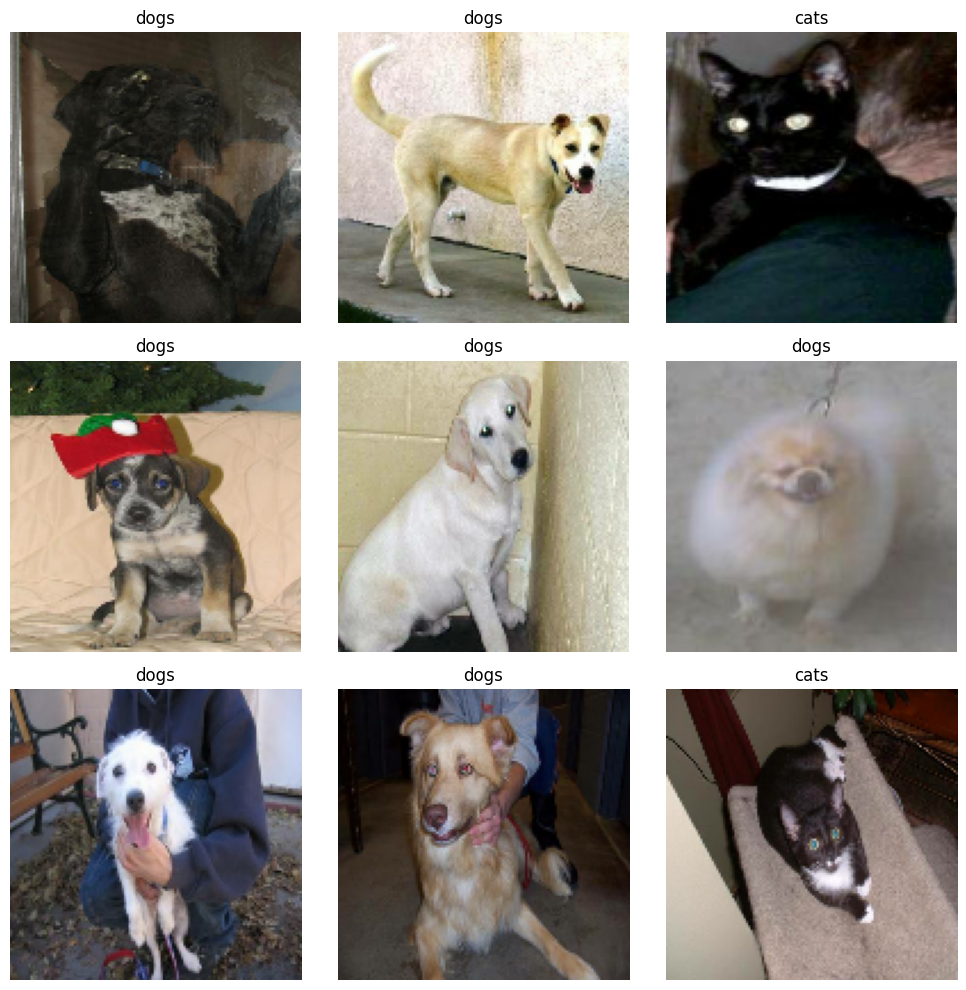

In [13]:
# Get one batch of images and labels
images, labels = next(iter(train_data))

# Select 9 random images from the batch
random_indices = np.random.choice(len(images), 9, replace=False)

plt.figure(figsize=(10, 10))

for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[idx].numpy().astype("uint8"))
    plt.title(class_names[labels[idx]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 🧠 CNN Model Architecture

I built a simple CNN from scratch using TensorFlow/Keras.

The architecture consists of:

- 3 Convolutional layers
- Max Pooling layers
- Flatten layer
- Dense layer
- Softmax output layer

The convolutional layers learn visual features from the images,
while the dense layers perform the final classification.

In [14]:
model = models.Sequential([
    layers.Input(shape=(128,128,3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(2, activation='softmax')

])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## ⚙️ Model Compilation

The model is compiled using:

- Optimizer: Adam
- Loss: Sparse Categorical Crossentropy
- Metric: Accuracy

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## 🚀 Model Training

The CNN is trained for **6 epochs** using the training dataset
and validated using the validation dataset.

In [17]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=6
)

Epoch 1/6


c:\Apeetha\cat_vs_dog_cnn\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


201/201 ━━━━━━━━━━━━━━━━━━━━ 40s 189ms/step - accuracy: 0.5895 - loss: 0.6636 - val_accuracy: 0.6790 - val_loss: 0.5955
Epoch 2/6
201/201 ━━━━━━━━━━━━━━━━━━━━ 39s 194ms/step - accuracy: 0.7057 - loss: 0.5660 - val_accuracy: 0.6533 - val_loss: 0.6150
Epoch 3/6
201/201 ━━━━━━━━━━━━━━━━━━━━ 39s 192ms/step - accuracy: 0.7498 - loss: 0.5060 - val_accuracy: 0.7508 - val_loss: 0.5069
Epoch 4/6
201/201 ━━━━━━━━━━━━━━━━━━━━ 37s 186ms/step - accuracy: 0.7884 - loss: 0.4593 - val_accuracy: 0.7445 - val_loss: 0.5222
Epoch 5/6
201/201 ━━━━━━━━━━━━━━━━━━━━ 37s 183ms/step - accuracy: 0.8187 - loss: 0.3934 - val_accuracy: 0.7345 - val_loss: 0.5800
Epoch 6/6
201/201 ━━━━━━━━━━━━━━━━━━━━ 37s 183ms/step - accuracy: 0.8638 - loss: 0.3175 - val_accuracy: 0.7589 - val_loss: 0.5210


## 🔍 Prediction on a New Image

The trained model is tested on a new image that was not directly
used during training.

The model predicts the class and provides a confidence score.

In [18]:
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

img = load_img(
    "pexels-itzmebarzy-29020872.jpg",
    target_size=(128,128)
)

img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, axis = 0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("Predicted animal:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Predicted animal: cats
Confidence: 57.94906


## 📊 Model Evaluation

The model is evaluated on the separate test dataset to measure
its performance on unseen images.

The final test loss and test accuracy are reported below.

In [19]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.7632 - loss: 0.5608
Test Loss: 0.5608248710632324
Test Accuracy: 0.7632229328155518


## 📈 Training Performance

The following plots show how training and validation accuracy
and loss changed across the epochs.

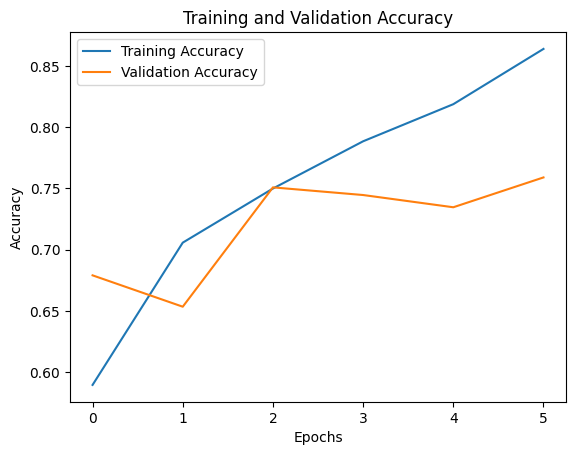

In [20]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

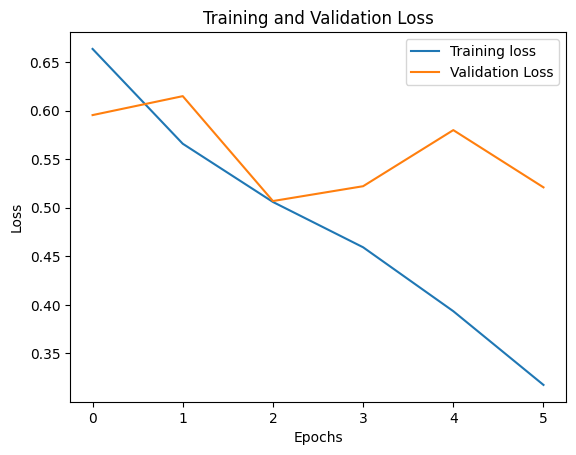

In [21]:
plt.plot(history.history['loss'], label = "Training loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()